In [2]:
import numpy as np

def least_squares(z, y):
    z = np.asarray(z, dtype=float)
    y = np.asarray(y, dtype=float)

    M = z.T @ z
    s = z.T @ y

    # More robust than np.linalg.solve for singular matrices
    w = np.linalg.lstsq(M, s, rcond=None)[0]

    predictions = z @ w
    R = np.sum((predictions - y) ** 2)

    return w, R


def quadratic_features(x):
    x = np.atleast_1d(x)

    return np.concatenate([
        [1],
        x,
        x ** 2
    ])


data = np.loadtxt("traindata.txt")

X = data[:, :-1]   # Keep X two-dimensional
y = data[:, -1]

quadratic_error = cross_validate(
    X,
    y,
    quadratic_features,
    k=5
)

In [3]:
import numpy as np

data = np.loadtxt("traindata.txt")
X = data[:, :-1]          # Keep X two-dimensional
y = data[:, -1]

def quadratic_features(x):
    x = np.asarray(x, dtype=float).ravel()
    return np.concatenate(([1.0], x, x ** 2))

quadratic_error = cross_validate(
    X,
    y,
    quadratic_features,
    k=5
)

print("Quadratic cross-validation error:", quadratic_error)


Quadratic cross-validation error: (array([52.88873837, 59.09606972, 61.43248354, 66.24877743, 68.25684801]), array([150.64115076,  91.10324158,  80.32010685,  58.19147929,
        58.20402742]))


Quadratic training error: 61.584583414411256
Quadratic validation error: 87.69200117992139


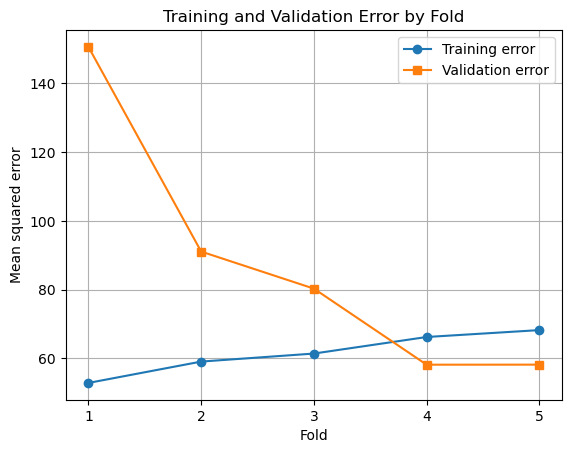

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def cross_validate(X, y, feature_function, k=5):
    X = np.asarray(X)
    y = np.asarray(y)

    folds = np.array_split(np.arange(len(y)), k)
    training_errors = []
    validation_errors = []

    for test_indices in folds:
        train_indices = np.setdiff1d(np.arange(len(y)), test_indices)

        Z_train = np.array([feature_function(x) for x in X[train_indices]])
        Z_test = np.array([feature_function(x) for x in X[test_indices]])

        w, _ = least_squares(Z_train, y[train_indices])

        train_predictions = Z_train @ w
        test_predictions = Z_test @ w

        train_error = np.mean(
            (train_predictions - y[train_indices]) ** 2
        )
        validation_error = np.mean(
            (test_predictions - y[test_indices]) ** 2
        )

        training_errors.append(train_error)
        validation_errors.append(validation_error)

    return np.asarray(training_errors), np.asarray(validation_errors)


training_errors, validation_errors = cross_validate(
    X,
    y,
    quadratic_features,
    k=5
)

quadratic_error = np.mean(validation_errors)

print("Quadratic training error:", np.mean(training_errors))
print("Quadratic validation error:", quadratic_error)

folds = range(1, len(training_errors) + 1)

plt.plot(folds, training_errors, marker="o", label="Training error")
plt.plot(folds, validation_errors, marker="s", label="Validation error")

plt.xlabel("Fold")
plt.ylabel("Mean squared error")
plt.title("Training and Validation Error by Fold")
plt.xticks(list(folds))
plt.legend()
plt.grid(True)
plt.show()

LOOCV training error: 63.31187943027597
LOOCV validation error: 66.05008992556098


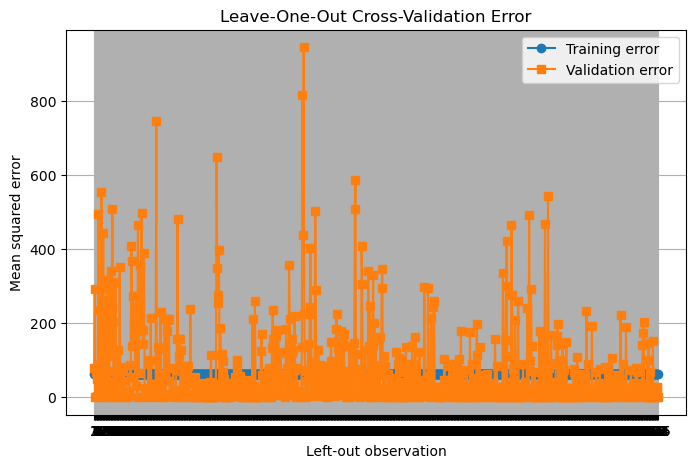

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def leave_one_out_cv(X, y, feature_function):
    X = np.asarray(X)
    y = np.asarray(y)

    training_errors = []
    validation_errors = []

    for i in range(len(y)):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i)

        X_test = X[i:i + 1]
        y_test = y[i:i + 1]

        Z_train = np.array([
            feature_function(x) for x in X_train
        ])
        Z_test = np.array([
            feature_function(x) for x in X_test
        ])

        w, _ = least_squares(Z_train, y_train)

        train_predictions = Z_train @ w
        test_predictions = Z_test @ w

        training_errors.append(
            np.mean((train_predictions - y_train) ** 2)
        )
        validation_errors.append(
            np.mean((test_predictions - y_test) ** 2)
        )

    return (
        np.asarray(training_errors),
        np.asarray(validation_errors)
    )


loo_training_errors, loo_validation_errors = leave_one_out_cv(
    X,
    y,
    quadratic_features
)

loo_error = np.mean(loo_validation_errors)

print("LOOCV training error:", np.mean(loo_training_errors))
print("LOOCV validation error:", loo_error)

observations = np.arange(1, len(y) + 1)

plt.figure(figsize=(8, 5))
plt.plot(
    observations,
    loo_training_errors,
    marker="o",
    label="Training error"
)
plt.plot(
    observations,
    loo_validation_errors,
    marker="s",
    label="Validation error"
)

plt.xlabel("Left-out observation")
plt.ylabel("Mean squared error")
plt.title("Leave-One-Out Cross-Validation Error")
plt.xticks(observations)
plt.legend()
plt.grid(True)
plt.show()